In [33]:
import sys
import os
import pandas as pd
import numpy as np
import csv
import pip
import seaborn as sns
import matplotlib.pyplot as plt
from functools import reduce
import statsmodels.api as sm
import linearmodels as lm
from linearmodels import PanelOLS, RandomEffects
from scipy import stats
from linearmodels import RandomEffects
import statsmodels.api as sm
from linearmodels.panel import compare

In [34]:
final_df = pd.read_csv("prepared_data_for_regression.csv")
print(final_df.head(5))

      country  year  incidence  mortality           gdp       bmi    pop_65  \
0        fiji  2000  39.310026  33.722967   9426.113813  0.303726  3.437768   
1    cambodia  2000  11.807551  10.664151   1922.031791  0.100004  2.816518   
2    kiribati  2000  13.866566  12.601468   2481.415243  0.307055  3.413156   
3  kazakhstan  2000  35.284421  18.655098  12935.864368  0.291659  6.693366   
4     jamaica  2000  50.404926  25.599975   9518.231763  0.240683  6.060642   

   urban_pop  fertility  labor_rate  internet  health_exp  smoking  
0     47.908      2.992      37.841  1.496850    3.424412     15.9  
1     18.586      3.794      77.834  0.047023    6.482484     23.5  
2     42.958      4.071         NaN  1.785230    7.773798     53.9  
3     56.098      1.898      65.381  0.668594    4.160324     12.0  
4     51.814      2.345      58.147  3.115780    5.644625      8.8  


In [35]:
initial_countries=final_df['country'].nunique()
print(initial_countries)

171


In [36]:
initial_years=final_df['year'].nunique()
print(initial_years)

24


# OECD  Countries :

In [37]:
oecd_countries = ['austria', 'australia', 'belgium', 'canada', 'chile', 
                  'colombia', 'czech', 'denmark', 'estonia', 'finland', 
                  'france', 'germany', 'greece', 'hungary', 'iceland', 'ireland', 
                  'israel', 'italy', 'japan', 'korea', 'latvia', 'lithuania', 'luxembourg', 
                  'mexico', 'netherlands', 'new zealand', 'norway', 'poland', 'portugal', 'slovakia', 
                  'slovenia', 'spain', 'sweden', 'switzerland', 'turkiye', 'united kingdom', 'united states', 'costa rica']
print(len(oecd_countries))

38


# Calculate MIR (mortality to incidence rate):

In [38]:
MIR = final_df['mortality'] / final_df['incidence']
print(MIR)

0       0.857872
1       0.903164
2       0.908766
3       0.528706
4       0.507886
          ...   
4061    1.314799
4062    0.132557
4063    0.326997
4064    0.313276
4065    0.463373
Length: 4066, dtype: float64


# Creat Dummy Variables:

In [39]:
final_df['is_oecd'] = final_df['country'].isin(oecd_countries).astype(int)

# creat interaction :

is_oecd
0    3274
1     792
Name: count, dtype: int64


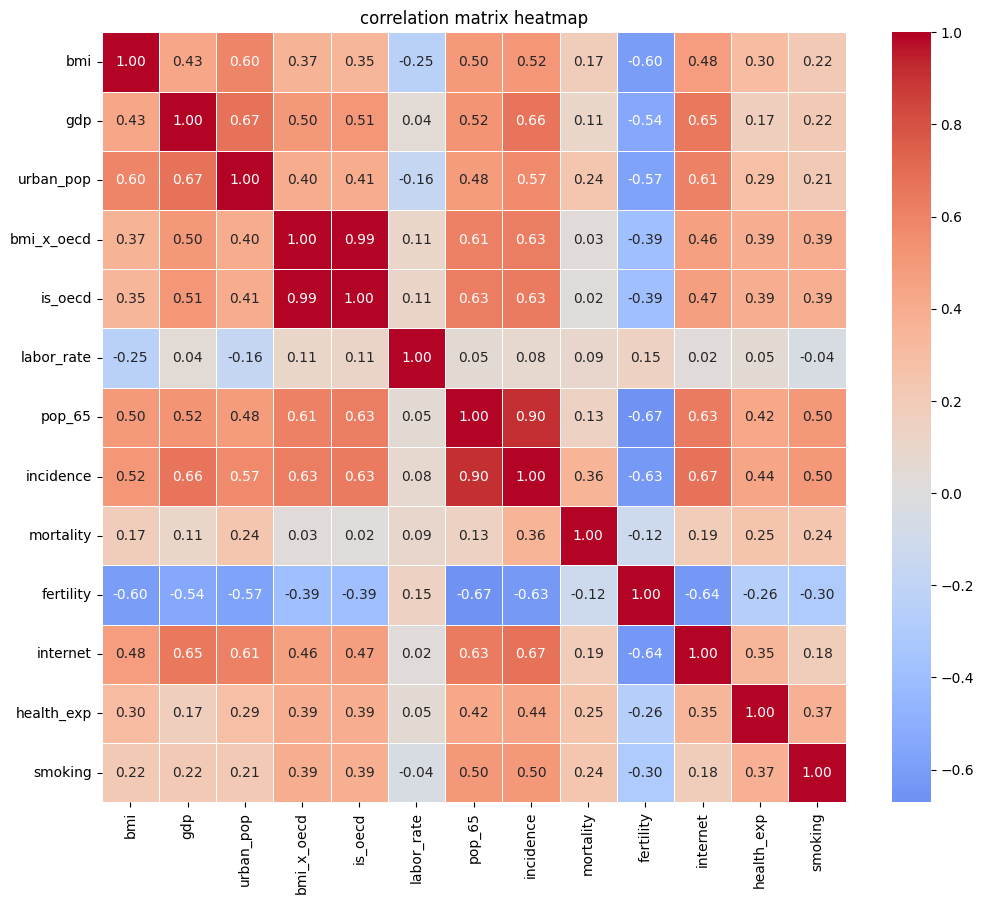

In [40]:
final_df['bmi_x_oecd'] = final_df['bmi']* final_df['is_oecd']
print(final_df['is_oecd'].value_counts())
columns_for_heatmap=['bmi', 'gdp', 'urban_pop', 'bmi_x_oecd', 'is_oecd', 'labor_rate', 'pop_65'
                      ,'incidence', 'mortality', 'fertility','internet','health_exp','smoking']
correlation_matrix = final_df[columns_for_heatmap].corr()
plt.figure(figsize= (12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", center=0, linewidths=0.5)
plt.title('correlation matrix heatmap')
plt.show()

# Dummy Variables: 

In [41]:
final_df['is_oecd']= final_df['country'].str.lower().str.strip().isin(oecd_countries).astype(int)
print(final_df['is_oecd'].value_counts())

is_oecd
0    3274
1     792
Name: count, dtype: int64


1. Aging Society Dummy: Based on WHO standards, societies with >10% population over 65 are considered "ageing" or "aged". This captures potential non-linear increases in cancer incidence due to population structure.

In [42]:
final_df['dm_high_aging_society'] = (final_df['pop_65'] > 10).astype(int)
print(final_df['dm_high_aging_society'].value_counts())

dm_high_aging_society
0    2740
1    1326
Name: count, dtype: int64


2. High Life Expectancy Dummy threshold of 75 years represents advanced healthcare systems and higher probability of disease detection.

In [43]:
print(final_df[['year', 'country', 'is_oecd', 'dm_high_aging_society']].head(100))

    year              country  is_oecd  dm_high_aging_society
0   2000                 fiji        0                      0
1   2000             cambodia        0                      0
2   2000             kiribati        0                      0
3   2000           kazakhstan        0                      0
4   2000              jamaica        0                      0
..   ...                  ...      ...                    ...
95  2000               cyprus        0                      0
96  2000  antigua and barbuda        0                      0
97  2001                malta        0                      1
98  2001               canada        1                      1
99  2000                nepal        0                      0

[100 rows x 4 columns]


# interaction of is_oecd variable and gdp

In [44]:
final_df['log_gdp']= np.log(final_df['gdp'])
final_df['log_gdp_is_oecd']= final_df['log_gdp']*final_df['is_oecd']
print(final_df['log_gdp_is_oecd'].head(5))

0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: log_gdp_is_oecd, dtype: float64


In [45]:
final_df['is_oecd'] = 0
final_df.loc[final_df['country'].isin(oecd_countries), 'is_oecd'] = 1

# interaction of is_oecd variable and gdp
final_df['log_gdp'] = np.log(final_df['gdp'])
final_df['log_gdp_is_oecd'] = final_df['log_gdp'] * final_df['is_oecd']
# Filling NaNs in Interaction Term: Since 'NaN * 0 = NaN' in Python, rows where is_oecd is 0 but log_gdp is missing(NAN) 
# would incorrectly stay as NaN (and be counted in the results), then filled these with 0 to ensure only real OECD countries with data are counted.
final_df['log_gdp_is_oecd'] = final_df['log_gdp_is_oecd'].fillna(0)

# counting contries :
oecd_count = final_df[final_df['is_oecd'] == 1]['country'].nunique()
interaction_countries = final_df[final_df['log_gdp_is_oecd'] != 0]['country'].nunique()

In [46]:
print(final_df[['country','gdp','is_oecd','log_gdp_is_oecd','dm_high_aging_society']].sample(20).round(2))

                  country        gdp  is_oecd  log_gdp_is_oecd  \
1941  trinidad and tobago   34814.37        0             0.00   
2474             maldives   17581.77        0             0.00   
95                 cyprus   36124.78        0             0.00   
1682                benin    2732.01        0             0.00   
872                jordan    9977.76        0             0.00   
3655                chile   27892.99        1            10.24   
3684           seychelles   28635.36        0             0.00   
1721           kazakhstan   27946.16        0             0.00   
3501             cameroon    4843.65        0             0.00   
2818                benin    3155.45        0             0.00   
1996              albania   12525.80        0             0.00   
908      marshall islands    4075.58        0             0.00   
1256           luxembourg  135812.22        1            11.82   
2803         turkmenistan   11633.29        0             0.00   
147       

In [47]:
# # start_year=final_df['year'].min()
# end_year=final_df['year'].max()
# print(final_df[['year', 'country', 'dm_high_aging_society']].tail(100))
# start_count= final_df[final_df['year']== start_year]['dm_high_life_exp'].sum() 
# end_count=final_df[final_df['year']== end_year]['dm_high_life_exp'].sum()
# print(f"number of countries with high life_expectency in {start_count}")
# print(f"number of countries with high life_expectency in {end_count}")

# delet percentage of rows with missing value(NA):

In [48]:
# report of missing values
missing_report = (final_df.isnull().sum() / len(final_df)) * 100
print(missing_report[missing_report > 0])

gdp            2.729956
labor_rate     7.894737
internet       3.713724
health_exp     5.656665
smoking       14.461387
log_gdp        2.729956
dtype: float64


In [49]:
clean_df= final_df.dropna(subset=['incidence','mortality', 'gdp', 'pop_65', 'urban_pop', 'fertility', 'labor_rate', 'log_gdp_is_oecd', 'internet', 'health_exp', 'smoking'])
print(f" Missing values after deleting NA in clean_df: {clean_df.isnull().sum()}")

 Missing values after deleting NA in clean_df: country                  0
year                     0
incidence                0
mortality                0
gdp                      0
bmi                      0
pop_65                   0
urban_pop                0
fertility                0
labor_rate               0
internet                 0
health_exp               0
smoking                  0
is_oecd                  0
bmi_x_oecd               0
dm_high_aging_society    0
log_gdp                  0
log_gdp_is_oecd          0
dtype: int64


# Building stepwise regression

# Step 1: Adding Urban Population and log_gdp

In [50]:
df_step= clean_df.set_index(['country', 'year'])
exog_1_fe= sm.add_constant(df_step[['log_gdp', 'urban_pop']])
model_1_fe=PanelOLS(df_step['incidence'],exog_1_fe, entity_effects=True, time_effects=True).fit()
print(model_1_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              incidence   R-squared:                        0.0062
Estimator:                   PanelOLS   R-squared (Between):              0.1477
No. Observations:                3086   R-squared (Within):               0.1090
Date:                Tue, Mar 24 2026   R-squared (Overall):              0.1457
Time:                        12:41:29   Log-likelihood                   -9797.1
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      9.1082
Entities:                         137   P-value                           0.0001
Avg Obs:                       22.526   Distribution:                  F(2,2924)
Min Obs:                       12.000                                           
Max Obs:                       24.000   F-statistic (robust):             9.1082
                            

# Step 2: Adding Pop_65:

In [51]:
exog_2_fe = df_step[['log_gdp', 'urban_pop', 'pop_65']]
model_2_fe = PanelOLS(df_step['incidence'], exog_2_fe, entity_effects=True, time_effects=True).fit()
print(model_2_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              incidence   R-squared:                        0.0532
Estimator:                   PanelOLS   R-squared (Between):              0.6960
No. Observations:                3086   R-squared (Within):               0.3140
Date:                Tue, Mar 24 2026   R-squared (Overall):              0.6915
Time:                        12:41:29   Log-likelihood                   -9722.3
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      54.785
Entities:                         137   P-value                           0.0000
Avg Obs:                       22.526   Distribution:                  F(3,2923)
Min Obs:                       12.000                                           
Max Obs:                       24.000   F-statistic (robust):             54.785
                            

# Step 3: Adding Labor Rate:

In [52]:
exog_3_fe=sm.add_constant(df_step[['log_gdp', 'urban_pop', 'pop_65', 'labor_rate']])
model_3_fe=PanelOLS(df_step['incidence'], exog_3_fe, entity_effects=True, time_effects=True).fit()
print(model_3_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              incidence   R-squared:                        0.0536
Estimator:                   PanelOLS   R-squared (Between):              0.4362
No. Observations:                3086   R-squared (Within):               0.3160
Date:                Tue, Mar 24 2026   R-squared (Overall):              0.4321
Time:                        12:41:29   Log-likelihood                   -9721.7
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      41.362
Entities:                         137   P-value                           0.0000
Avg Obs:                       22.526   Distribution:                  F(4,2922)
Min Obs:                       12.000                                           
Max Obs:                       24.000   F-statistic (robust):             41.362
                            

# Step 4: Adding BMI:

In [53]:
exog_4_fe=sm.add_constant(df_step[['log_gdp','urban_pop', 'pop_65', 'labor_rate', 'bmi']])
model_4_fe=PanelOLS(df_step['incidence'], exog_4_fe, entity_effects=True, time_effects= True).fit()
print(model_4_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              incidence   R-squared:                        0.0537
Estimator:                   PanelOLS   R-squared (Between):              0.4371
No. Observations:                3086   R-squared (Within):               0.3179
Date:                Tue, Mar 24 2026   R-squared (Overall):              0.4330
Time:                        12:41:29   Log-likelihood                   -9721.6
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      33.124
Entities:                         137   P-value                           0.0000
Avg Obs:                       22.526   Distribution:                  F(5,2921)
Min Obs:                       12.000                                           
Max Obs:                       24.000   F-statistic (robust):             33.124
                            

# Step 5: Adding is_oecd as Dummy Variable:

In [54]:
exog_5_fe=sm.add_constant(df_step[['log_gdp','urban_pop', 'pop_65', 'labor_rate', 'bmi','log_gdp_is_oecd']])
model_5_fe=PanelOLS(df_step['incidence'], exog_5_fe, entity_effects=True, time_effects=True).fit()
print(model_5_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              incidence   R-squared:                        0.0565
Estimator:                   PanelOLS   R-squared (Between):             -0.3501
No. Observations:                3086   R-squared (Within):               0.3175
Date:                Tue, Mar 24 2026   R-squared (Overall):             -0.3485
Time:                        12:41:29   Log-likelihood                   -9717.0
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      29.135
Entities:                         137   P-value                           0.0000
Avg Obs:                       22.526   Distribution:                  F(6,2920)
Min Obs:                       12.000                                           
Max Obs:                       24.000   F-statistic (robust):             29.135
                            

# Step 6: Adding High aging society as Dummy Variable:

In [55]:
exog_6_fe = sm.add_constant(df_step[['log_gdp', 'urban_pop', 'pop_65', 'labor_rate', 'bmi','log_gdp_is_oecd', 'dm_high_aging_society']])
model_6_fe = PanelOLS(df_step['incidence'], exog_6_fe, entity_effects=True, time_effects=True).fit()
print(model_6_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              incidence   R-squared:                        0.0570
Estimator:                   PanelOLS   R-squared (Between):             -0.3541
No. Observations:                3086   R-squared (Within):               0.3210
Date:                Tue, Mar 24 2026   R-squared (Overall):             -0.3523
Time:                        12:41:29   Log-likelihood                   -9716.1
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      25.210
Entities:                         137   P-value                           0.0000
Avg Obs:                       22.526   Distribution:                  F(7,2919)
Min Obs:                       12.000                                           
Max Obs:                       24.000   F-statistic (robust):             25.210
                            

# Step 7: Adding High life exp as Dummy Variable:

In [57]:
exog_7_fe = sm.add_constant(df_step[['log_gdp', 'urban_pop', 'pop_65', 'labor_rate', 'bmi','log_gdp_is_oecd', 'dm_high_aging_society']])
model_7_fe = PanelOLS(df_step['incidence'], exog_7_fe, entity_effects=True, time_effects= True).fit()
print(model_7_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              incidence   R-squared:                        0.0570
Estimator:                   PanelOLS   R-squared (Between):             -0.3541
No. Observations:                3086   R-squared (Within):               0.3210
Date:                Tue, Mar 24 2026   R-squared (Overall):             -0.3523
Time:                        12:41:48   Log-likelihood                   -9716.1
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      25.210
Entities:                         137   P-value                           0.0000
Avg Obs:                       22.526   Distribution:                  F(7,2919)
Min Obs:                       12.000                                           
Max Obs:                       24.000   F-statistic (robust):             25.210
                            

# create labor_rate * is_oecd variable:

In [58]:
df_step['labor_rate * is_oecd']= df_step['labor_rate']* df_step['is_oecd']

# Step 8: Adding labor_rate * is_oecd:

In [59]:
exog_8_fe = sm.add_constant(df_step[['log_gdp', 'urban_pop', 'pop_65', 'labor_rate', 'bmi',
                                     'log_gdp_is_oecd', 'dm_high_aging_society', 'labor_rate * is_oecd']])
model_8_fe = PanelOLS(df_step['incidence'], exog_8_fe, entity_effects=True, time_effects= True).fit()
print(model_8_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              incidence   R-squared:                        0.0733
Estimator:                   PanelOLS   R-squared (Between):              0.0390
No. Observations:                3086   R-squared (Within):               0.2971
Date:                Tue, Mar 24 2026   R-squared (Overall):              0.0381
Time:                        12:41:58   Log-likelihood                   -9689.2
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      28.843
Entities:                         137   P-value                           0.0000
Avg Obs:                       22.526   Distribution:                  F(8,2918)
Min Obs:                       12.000                                           
Max Obs:                       24.000   F-statistic (robust):             28.843
                            

# Step 9: Adding internet:

In [60]:
exog_9_fe = sm.add_constant(df_step[['log_gdp', 'urban_pop', 'pop_65', 'labor_rate', 'bmi','log_gdp_is_oecd',
                                     'dm_high_aging_society', 'labor_rate * is_oecd','internet']])
model_9_fe = PanelOLS(df_step['incidence'], exog_9_fe, entity_effects=True, time_effects= True).fit()
print(model_9_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              incidence   R-squared:                        0.1475
Estimator:                   PanelOLS   R-squared (Between):              0.1694
No. Observations:                3086   R-squared (Within):               0.5364
Date:                Tue, Mar 24 2026   R-squared (Overall):              0.1719
Time:                        12:42:04   Log-likelihood                   -9560.5
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      56.066
Entities:                         137   P-value                           0.0000
Avg Obs:                       22.526   Distribution:                  F(9,2917)
Min Obs:                       12.000                                           
Max Obs:                       24.000   F-statistic (robust):             56.066
                            

# Step  10: Adding smoking:

In [61]:
exog_10_fe = sm.add_constant(df_step[['log_gdp', 'urban_pop', 'pop_65', 'labor_rate', 'bmi','log_gdp_is_oecd',
                                     'dm_high_aging_society', 'labor_rate * is_oecd','internet','smoking']])
model_10_fe = PanelOLS(df_step['incidence'], exog_10_fe, entity_effects=True, time_effects= True).fit()
print(model_10_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              incidence   R-squared:                        0.1956
Estimator:                   PanelOLS   R-squared (Between):              0.6059
No. Observations:                3086   R-squared (Within):               0.4730
Date:                Tue, Mar 24 2026   R-squared (Overall):              0.6015
Time:                        12:42:07   Log-likelihood                   -9470.8
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      70.908
Entities:                         137   P-value                           0.0000
Avg Obs:                       22.526   Distribution:                 F(10,2916)
Min Obs:                       12.000                                           
Max Obs:                       24.000   F-statistic (robust):             70.908
                            

# step 11: adding health_exp:

In [62]:
exog_11_fe = sm.add_constant(df_step[['log_gdp', 'urban_pop', 'pop_65', 'labor_rate', 'bmi','log_gdp_is_oecd','dm_high_aging_society',
                                      'labor_rate * is_oecd','internet','smoking','health_exp']])
model_11_fe = PanelOLS(df_step['incidence'], exog_11_fe, entity_effects=True, time_effects= True).fit()
print(model_11_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              incidence   R-squared:                        0.1991
Estimator:                   PanelOLS   R-squared (Between):              0.5671
No. Observations:                3086   R-squared (Within):               0.4544
Date:                Tue, Mar 24 2026   R-squared (Overall):              0.5629
Time:                        12:42:10   Log-likelihood                   -9464.1
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      65.870
Entities:                         137   P-value                           0.0000
Avg Obs:                       22.526   Distribution:                 F(11,2915)
Min Obs:                       12.000                                           
Max Obs:                       24.000   F-statistic (robust):             65.870
                            

# step 12: adding Fertality variable:

In [63]:
exog_12_fe = sm.add_constant(df_step[['log_gdp', 'urban_pop', 'pop_65', 'labor_rate', 
                                      'bmi','log_gdp_is_oecd','dm_high_aging_society', 
                                      'labor_rate * is_oecd','internet','smoking','health_exp','fertility']])
model_12_fe = PanelOLS(df_step['incidence'], exog_12_fe, entity_effects=True, time_effects= True).fit()
print(model_12_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              incidence   R-squared:                        0.2075
Estimator:                   PanelOLS   R-squared (Between):              0.6809
No. Observations:                3086   R-squared (Within):               0.5329
Date:                Tue, Mar 24 2026   R-squared (Overall):              0.6762
Time:                        12:42:13   Log-likelihood                   -9447.8
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      63.588
Entities:                         137   P-value                           0.0000
Avg Obs:                       22.526   Distribution:                 F(12,2914)
Min Obs:                       12.000                                           
Max Obs:                       24.000   F-statistic (robust):             63.588
                            

# Comparing results of all Fixed Effect models:

In [64]:
Compare_results_fixed_Effect = compare({
    'FE model 1': model_1_fe,
    'FE model 2': model_2_fe,
    'FE model 3': model_3_fe,
    'FE model 4': model_4_fe,
    'FE model 5': model_5_fe,
    'FE model 6': model_6_fe,
    'FE model 7': model_7_fe,
    'FE model 8': model_8_fe,
    'FE model 9': model_9_fe,
    'FE model 10': model_10_fe,
    'FE model 11': model_11_fe,
    'FE model 12': model_12_fe})

print(Compare_results_fixed_Effect)

                                                                                               Model Comparison                                                                                              
                              FE model 1     FE model 2     FE model 3     FE model 4     FE model 5     FE model 6     FE model 7     FE model 8     FE model 9    FE model 10    FE model 11    FE model 12
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Dep. Variable                  incidence      incidence      incidence      incidence      incidence      incidence      incidence      incidence      incidence      incidence      incidence      incidence
Estimator                       PanelOLS       PanelOLS       PanelOLS       PanelOLS       PanelOLS       PanelOLS       PanelOLS       PanelOLS       PanelOLS       PanelOLS 

In [65]:
with open('Comparison_incidence_Table.html', 'w') as f:
    f.write(Compare_results_fixed_Effect.summary.as_html())